# BÀI 1: HIỂU DỮ LIỆU, CHỌN DỮ LIỆU VÀ TIỀN XỬ LÝ
## Tập dữ liệu D1 - Hotel Booking Demand

### 1. Đề xuất bộ dữ liệu & Ma trận kỹ thuật

#### 1.1. Nguồn gốc, giấy phép, quy mô
- **Tên dataset**: Hotel Booking Demand
- **Đơn vị công bố / Nguồn tải**: ScienceDirect / Kaggle (công bố bởi Nuno Antonio, Ana Almeida, Luis Nunes) : https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand
- **Giấy phép**: CC0: Public Domain
- **Ngày tải**: 05/09/2026
- **Quy mô**: 119,390 bản ghi x 32 thuộc tính 

#### 1.2. Từ điển dữ liệu (Các thuộc tính chính)
| Thuộc tính | Ý nghĩa | Kiểu | Thang đo | Miền giá trị |
|---|---|---|---|---|
| `hotel` | Loại khách sạn | Hạng mục (string) | Định danh | Resort Hotel, City Hotel |
| `is_canceled` | Đơn phòng có bị hủy không | Số nguyên (int) | Nhị phân | 0 (Không), 1 (Hủy) |
| `lead_time` | Khoảng thời gian từ lúc đặt đến ngày nhận phòng | Số nguyên (int) | Tỉ lệ | >= 0 (số ngày) |
| `stays_in_weekend_nights` | Số đêm lưu trú vào cuối tuần | Số nguyên (int) | Tỉ lệ | >= 0 |
| `stays_in_week_nights` | Số đêm lưu trú vào ngày thường | Số nguyên (int) | Tỉ lệ | >= 0 |
| `adults` / `children` / `babies`| Số lượng người lớn / trẻ em / em bé | Số nguyên (int) | Tỉ lệ | >= 0 |
| `adr` | Giá phòng trung bình mỗi đêm | Số thực (float) | Tỉ lệ | Số thực |
| `market_segment` | Phân khúc thị trường | Hạng mục (string) | Định danh | Online TA, Offline TA/TO, Groups... |
| `company` / `agent` | ID công ty hoặc đại lý du lịch đặt phòng | Số nguyên (int) | Định danh | ID hoặc NULL |
| `reservation_status` | Trạng thái hiện tại của đơn đặt phòng | Hạng mục (string) | Định danh | Canceled, Check-Out, No-Show |

#### 1.3. Điều tra tri thức lĩnh vực & Đề xuất kỹ thuật
**Bối cảnh nghiệp vụ**: Dữ liệu ghi nhận thông tin giao dịch đặt phòng của hai loại khách sạn: City Hotel (Khách sạn thành phố) và Resort Hotel (Khu nghỉ dưỡng). Các thuộc tính mô tả chi tiết từ lúc khách hàng lên kế hoạch (`lead_time`, `market_segment`), cơ cấu người đi (`adults`, `children`), thời gian ở (`stays_in_weekend_nights`, `stays_in_week_nights`), cho đến mức giá chi trả (`adr`). Trong ngành khách sạn, việc khách hàng hủy phòng phút chót (is_canceled) gây thất thoát doanh thu rất lớn vì buồng phòng đó bị bỏ trống.

Từ hiểu biết đó, nhóm đề xuất **2 kỹ thuật khả thi** cho bộ D1:
- **Phân lớp (Classification)**: Bộ dữ liệu có chứa biến mục tiêu rời rạc `is_canceled` (0 và 1) mang ý nghĩa quan trọng đối với khách sạn. Việc dự đoán một booking mới có nguy cơ hủy hay không dựa trên các thuộc tính lúc đặt phòng (như lead_time xa, khách lẻ hay đoàn) sẽ giúp khách sạn ra quyết định giữ chỗ hoặc overbooking để tối ưu hóa doanh thu. Vì thế khả năng Phân lớp là hoàn toàn hợp lý.
- **Gom cụm (Clustering)**: Dữ liệu chứa rất nhiều thuộc tính biểu hiện *hành vi* của khách hàng (chẳng hạn thời gian đặt phòng trước `lead_time`, giá `adr`, số đêm ở, và cơ cấu gia đình). Các bản ghi này có thể tự nhiên phân thành các nhóm khách hàng tương đồng có ý nghĩa lớn (ví dụ: nhóm khách gia đình đặt phòng đi nghỉ dưỡng dài ngày có kế hoạch trước, nhóm khách công tác đặt phòng ở liền ngắn ngày). Xác định được các cụm này giúp khách sạn cá nhân hóa Marketing. Vì thế khả năng Gom cụm rất khả thi.

#### 1.4. Ma trận bộ dữ liệu × kỹ thuật
| Bộ dữ liệu | Phân lớp | Luật kết hợp | Gom cụm |
|---|:---:|:---:|:---:|
| **D1: Hotel Booking Demand** | **X** | | **X** |
\n

In [14]:
from IPython import display
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Đọc dữ liệu
df = pd.read_csv('../data/raw/hotel_bookings.csv')
print("Kích thước tập dữ liệu:", df.shape)
display(df.head())

Kích thước tập dữ liệu: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### 2. Điều tra tiền xử lý
Nguyên tắc xuyên suốt: Quá trình khảo sát và tiền xử lý được lập luận dựa trên lý do nghiệp vụ của chính bộ dữ liệu.

#### 2.1. Thêm / xóa / biến đổi thuộc tính: Xóa thuộc tính do rò rỉ nhãn (Data Leakage)
- **Thuộc tính bị xóa**: `reservation_status` và `reservation_status_date`.
- **Vì**: Tri thức lĩnh vực cho thấy hai thuộc tính này ghi nhận "trạng thái cuối cùng" của đơn đặt phòng (khách đã Check-Out hay đã Canceled). Nếu sử dụng chúng làm biến đầu vào để dự đoán biến mục tiêu `is_canceled` ở thì tương lai, mô hình sẽ bị **rò rỉ nhãn (Data Leakage)**. Trong thực tế, lúc dự đoán một đơn phòng mới, ta hoàn toàn chưa có 2 thông tin này.\n

In [15]:
# Loại bỏ các cột gây rò rỉ nhãn
df = df.drop(columns=['reservation_status', 'reservation_status_date'])
print("Các cột sau khi xóa:", df.columns.tolist())

Các cột sau khi xóa: ['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']


#### 2.2. Giá trị thiếu (Missing values)
- **Tỉ lệ thiếu**: `company` (~94.3%), `agent` (~13.7%), `country` (~0.4%), `children` (~0.003%).
- **Cơ chế thiếu & Nhận định**: 
  - Thiếu ở `company` và `agent` là hiện tượng **thiếu có hệ thống**, vì trong ngành du lịch, không phải ai cũng đặt qua đại lý hay công ty. Khách tự đặt phòng cá nhân sẽ để trống thông tin này.
  - Việc thiếu ở `country` và `children` mang tính ngẫu nhiên (lỗi nhập liệu hoặc bỏ sót).
- **Cách xử lý & Giải thích**:
  - **`company` và `agent`**: Điền giá trị `0`. Lý do: Xác nhận đây không phải là lỗi dữ liệu, mà bản chất là khách cá nhân không thông qua tổ chức thứ 3. Gán `0` mang ý nghĩa là "Không có đại lý/công ty".
  - **`country`**: Điền bằng giá trị xuất hiện nhiều nhất (Mode). Vì tỉ lệ thiếu rất thấp (0.4%) và thuộc tính này là hạng mục (categorical), việc điền Mode không làm sai lệch phân phối.
  - **`children`**: Điền `0`. Lý do nghiệp vụ: Khi nhập liệu, nhân viên thường bỏ trống nếu khách không đi kèm trẻ em, nên bản chất nó là 0 đứa trẻ.\n

In [16]:
# Kiểm tra tỷ lệ missing values
missing_percent = (df.isnull().sum() / len(df)) * 100
print("Tỷ lệ missing values:\
", missing_percent[missing_percent > 0])

# Xử lý
df['company'] = df['company'].fillna(0)
df['agent'] = df['agent'].fillna(0)
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['children'] = df['children'].fillna(0)

print("\
Số lượng missing values sau xử lý:", df.isnull().sum().sum())

Tỷ lệ missing values: children     0.003350
country      0.408744
agent       13.686238
company     94.306893
dtype: float64
Số lượng missing values sau xử lý: 0


#### 2.3. Nhiễu và ngoại lai (Outliers)
- **Cách phát hiện**: Sử dụng tri thức lĩnh vực kết hợp với trực quan hóa bằng Boxplot để kiểm tra các thuộc tính định lượng.
- **Mức độ vi phạm**:
  - Có 180 bản ghi có tổng số khách (`adults` + `children` + `babies`) bằng 0.
  - Có 1961 bản ghi có `adr` (giá phòng trung bình đêm) nhỏ hơn hoặc bằng 0, hoặc có mức giá quá cao phi thực tế (chẳng hạn có 1 dòng adr lên tới 5400).
- **Quyết định xử lý & Lý giải**: 
  - **Loại bỏ** các bản ghi không có khách (`adults + children + babies == 0`). Lý do: Đơn đặt phòng không có người ở là một giao dịch ảo hoặc lỗi nhập liệu.
  - **Loại bỏ** các bản ghi có `adr <= 0` hoặc `adr > 5000`. Lý do: Giá phòng trung bình phải lớn hơn 0 để sinh doanh thu. Các giá trị âm, hoặc giá quá cao (outlier cực đoan) gây nhiễu rất mạnh tới thuật toán Gom cụm (khiến các tâm cụm K-Means bị kéo lệch) và hồi quy logistic trong Phân lớp.

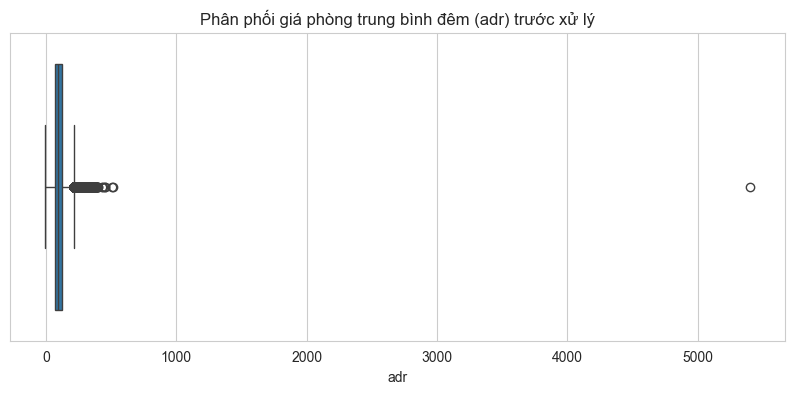

Kích thước dữ liệu sau khi xử lý ngoại lai: (117398, 30)


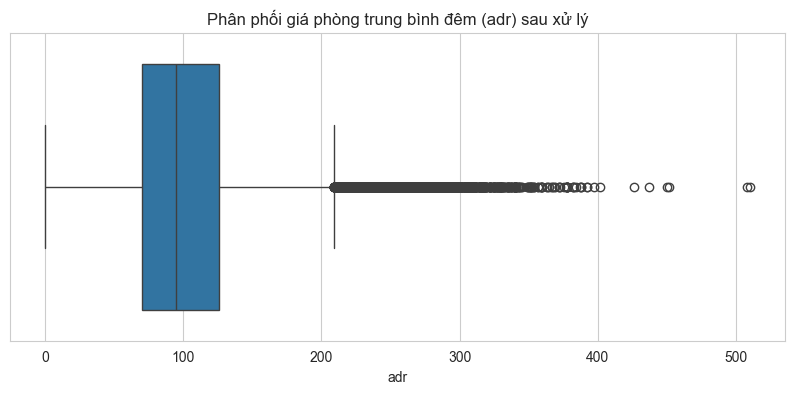

In [17]:
# Vẽ Boxplot kiểm tra adr trước khi xử lý
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['adr'])
plt.title('Phân phối giá phòng trung bình đêm (adr) trước xử lý')
plt.show()

# Xử lý đơn đặt phòng không có người
df = df[(df['adults'] + df['children'] + df['babies']) > 0]

# Xử lý ngoại lai cho adr
df = df[(df['adr'] > 0) & (df['adr'] <= 5000)]

print("Kích thước dữ liệu sau khi xử lý ngoại lai:", df.shape)

# Vẽ Boxplot kiểm tra adr sau khi xử lý
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['adr'])
plt.title('Phân phối giá phòng trung bình đêm (adr) sau xử lý')
plt.show()

#### 2.4. Thêm thuộc tính (Feature Engineering)
- **Tạo biến mới**:
  - `total_stay` = `stays_in_weekend_nights` + `stays_in_week_nights`
  - `total_people` = `adults` + `children` + `babies`
  - `is_family` = 1 (nếu có trẻ em/em bé) và 0 (nếu không có).
- **vì**: Thay vì để các biến thành phần rời rạc, các biến dẫn xuất này tóm tắt trực diện hành vi lưu trú (tổng số ngày ở, quy mô nhóm khách) và rất có giá trị trong việc phân định các "Cụm" gia đình đi du lịch dài ngày so với khách cá nhân đi công tác ngắn ngày.

In [18]:
# Tạo các biến mới
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_people'] = df['adults'] + df['children'] + df['babies']
df['is_family'] = ((df['children'] + df['babies']) > 0).astype(int)

display(df[['stays_in_weekend_nights', 'stays_in_week_nights', 'total_stay', 'adults', 'children', 'babies', 'total_people', 'is_family']].head())

,stays_in_weekend_nights,stays_in_week_nights,total_stay,adults,children,babies,total_people,is_family
2,0,1,1,1,0.0,0,1.0,0
3,0,1,1,1,0.0,0,1.0,0
4,0,2,2,2,0.0,0,2.0,0
5,0,2,2,2,0.0,0,2.0,0
6,0,2,2,2,0.0,0,2.0,0


#### 2.5. Biến đổi thuộc tính (Encoding & Scaling)
- **Mã hóa (One-Hot Encoding)**: Lý do: Các thuật toán máy học được sử dụng trong bài yêu cầu dữ liệu đầu vào ở dạng số. Các thuộc tính dạng chuỗi như hotel, meal, market_segment, deposit_type không thể đưa trực tiếp vào quá trình tính toán, đặc biệt đối với các thuật toán dựa trên khoảng cách như K-Means và DBSCAN. Vì vậy, nhóm sử dụng One-Hot Encoding để chuyển các biến hạng mục thành các biến nhị phân 0/1.
- **Chuẩn hóa (StandardScaler)**: Cho `lead_time`, `adr`, `total_stay`. Lý do: Kỹ thuật Gom cụm (như K-Means, DBSCAN) sử dụng độ đo khoảng cách (Euclidean distance). Nếu không co giãn, thuộc tính có miền giá trị lớn (như `lead_time`) sẽ lấn át hoàn toàn thuộc tính có miền nhỏ (như `total_stay`), khiến thuật toán Gom cụm bị sai lệch. Do đó bước này là **bắt buộc**.

In [19]:
# Mã hóa các biến hạng mục
categorical_cols = ['hotel', 'meal', 'market_segment', 'deposit_type']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("Kích thước tập dữ liệu sau One-Hot Encoding:", df.shape)

# Chuẩn hóa các biến định lượng
scaler = StandardScaler()
scale_cols = ['lead_time', 'adr', 'total_stay']
df[scale_cols] = scaler.fit_transform(df[scale_cols])
display(df[scale_cols].head())

Kích thước tập dữ liệu sau One-Hot Encoding: (117398, 43)


,lead_time,adr,total_stay
2,-0.917518,-0.610200,-0.971235
3,-0.861398,-0.610200,-0.971235
4,-0.852045,-0.117706,-0.575861
5,-0.852045,-0.117706,-0.575861
6,-0.982992,0.075009,-0.575861


In [20]:
# Lưu dữ liệu đã tiền xử lý
import os
os.makedirs('data/processed', exist_ok=True)
df.to_csv('data/processed/hotel_bookings_processed.csv', index=False)
print("Đã lưu tập dữ liệu tiền xử lý tại: 'data/processed/hotel_bookings_processed.csv'")

Đã lưu tập dữ liệu tiền xử lý tại: 'data/processed/hotel_bookings_processed.csv'
